# k-Nearest Neighbors classification on Iris

This tutorial builds a k-nearest neighbors (k-NN) classifier for `../dataset/iris.csv`. It is intended for learners familiar with basic Python and pandas.

By the end, you will be able to load the data with pandas, prepare and scale the features, train a k-NN classifier with `k = 3`, evaluate it, and predict the species of a new flower.

## Outline

1. Load and inspect the data
2. Prepare the features and target
3. Split the data into training and test sets
4. Train a k-NN classifier with `k = 3`
5. Evaluate the model
6. Predict a new observation

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

## 1. Load and inspect the data

The notebook is stored in `knn/`, so the dataset is one directory above it.

In [11]:
DATA_PATH = Path("../dataset/iris.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH.resolve()}. "
        "Start Jupyter from the knn directory or update DATA_PATH."
    )

iris = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {iris.shape}")
iris.head()

Dataset shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [12]:
print("Missing values per column:")
print(iris.isna().sum())
print("\nClass counts:")
print(iris["Species"].value_counts())

Missing values per column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Class counts:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


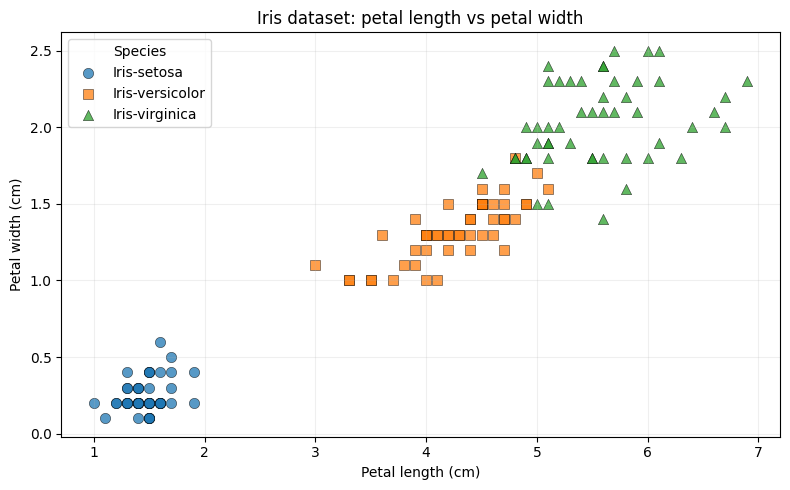

In [13]:
# Plot two features, using both color and marker shape for the species.
class_styles = {
    "Iris-setosa": {"color": "tab:blue", "marker": "o"},
    "Iris-versicolor": {"color": "tab:orange", "marker": "s"},
    "Iris-virginica": {"color": "tab:green", "marker": "^"},
}

plt.figure(figsize=(8, 5))
for species, style in class_styles.items():
    species_data = iris[iris["Species"] == species]
    plt.scatter(
        species_data["PetalLengthCm"],
        species_data["PetalWidthCm"],
        label=species,
        color=style["color"],
        marker=style["marker"],
        s=55,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.4,
    )

plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Iris dataset: petal length vs petal width")
plt.legend(title="Species")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 2. Prepare the features and target

`Id` is only a row identifier, so it must not be used as a predictor. The four flower measurements are the features, and `Species` is the target.

In [14]:
FEATURES = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm",
]
TARGET = "Species"

X = iris[FEATURES]
y = iris[TARGET]

print("Features:", FEATURES)
print("Classes:", sorted(y.unique()))

Features: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


## 3. Create training and test sets

The stratified split preserves the proportion of each species in both sets. The test set remains unseen while the model is trained.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training observations: {len(X_train)}")
print(f"Test observations: {len(X_test)}")

Training observations: 120
Test observations: 30


## 4. Scale the features and train the classifier

k-NN compares distances, so variables measured on larger scales can dominate the result. Fit the scaler on the training data only, apply it to both sets, and train the classifier with `k = 3`.

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train_scaled, y_train)

print("Classifier trained with k = 3")

Classifier trained with k = 3


## 5. Evaluate the classifier

Accuracy summarizes the overall result. The classification report and confusion matrix show performance for each species.

Test accuracy: 0.933

                 precision    recall  f1-score   support

    Iris-setosa      1.000     1.000     1.000        10
Iris-versicolor      0.833     1.000     0.909        10
 Iris-virginica      1.000     0.800     0.889        10

       accuracy                          0.933        30
      macro avg      0.944     0.933     0.933        30
   weighted avg      0.944     0.933     0.933        30



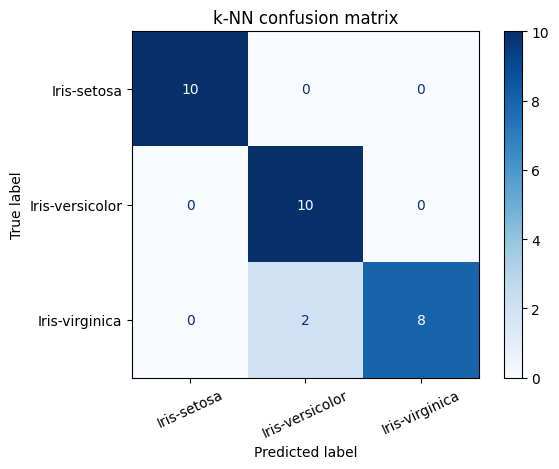

In [17]:
y_pred = model.predict(X_test_scaled)

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, digits=3))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    xticks_rotation=25,
)
plt.title("k-NN confusion matrix")
plt.tight_layout()
plt.show()

## 6. Predict a new flower

Pass new measurements in a DataFrame with the same column names and units as the training data, then scale them before prediction.

In [18]:
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=FEATURES,
)

new_flower_scaled = scaler.transform(new_flower)
predicted_species = model.predict(new_flower_scaled)[0]
class_probabilities = pd.Series(
    model.predict_proba(new_flower_scaled)[0],
    index=model.classes_,
    name="probability",
).sort_values(ascending=False)

print("Predicted species:", predicted_species)
class_probabilities

Predicted species: Iris-setosa


Iris-setosa        1.0
Iris-versicolor    0.0
Iris-virginica     0.0
Name: probability, dtype: float64